Fabián Andrez De La Cruz

00326281

# PSET #4

# Acceso y preparación de los datos

In [792]:
import pandas as pd

In [793]:
visits = pd.read_csv('../data/raw/visits_log_us.csv')
orders = pd.read_csv('../data/raw/orders_log_us.csv')
costs = pd.read_csv('../data/raw/costs_us.csv')

Hagamos una breve exploración inicial de los datos para ver si hallamos valores ausentes o algo interesante.

In [794]:
def exploracion_inicial (df):
    print('-'*30+' Primeras filas '+'-'*30)
    print(df.head(10))
    print('-'*30+' Primeras filas '+'-'*30)
    print(df.info())
    print('-'*30+' Duplicados '+'-'*30)
    print(df.duplicated().sum())
    print('-'*30+' Ausentes '+'-'*30)
    print(df.isna().sum())

In [795]:
exploracion_inicial(visits)

------------------------------ Primeras filas ------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6  

 No hay ni ausentes ni duplicados. End Ts y Start Ts son claramente fechas, tenemos que ajustar esto ya que pandas los tiene como tipo objeto. Device, Source Id y Uid se encuentran bien.

In [796]:
exploracion_inicial(costs)

------------------------------ Primeras filas ------------------------------
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24
------------------------------ Primeras filas ------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None
------------------------------ Duplicados ------------------------------
0
------------------------------ Ausentes -----

No hay ni ausentes ni duplicados. dt es claramente una fecha, tenemos que ajustar esto ya que pandas lo tiene como tipo objeto. source_id y costs se encuentran bien.

In [797]:
exploracion_inicial(orders)

------------------------------ Primeras filas ------------------------------
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   1074355127080856382
------------------------------ Primeras filas ------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  

No hay ni ausentes ni duplicados. Buy ts es claramente una fecha, tenemos que ajustar esto ya que pandas lo tiene como tipo objeto. Revenue y Uid se encuentran bien.

Veo que el nombre de las columnas no es igual para todos los df. Voy a cambiar a que todo sea en minúsculas y si hay espacios que se rellene con '_'

### Ajustando 'Visits'

Iniciemos ajustando el tipo de datos.

In [798]:
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])

In [799]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


Ahora con el tipo definido, cambiemos el nombre de las columnas

In [800]:
visits.columns = [column.lower().replace(' ','_') for column in visits.columns]

In [801]:
visits.columns

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

Visits está listo.

### Ajustando 'Costs'

Todo esta en minúsculas así que lo único a cambiarse es el tipo de dato.

In [802]:
costs['dt']=pd.to_datetime(costs['dt'])

In [803]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


Perfecto, costs está listo.

### Ajustando 'Orders'

Hay que cambiar el tipo de dato y las columnas.

In [804]:
orders['Buy Ts']=pd.to_datetime(orders['Buy Ts'])

In [805]:
orders.columns = [column.lower().replace(' ','_') for column in orders.columns]

In [806]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


Todo perfecto,ahora guardemos esta data limpia en interim.

In [807]:
visits.to_csv('../data/interim/visits.csv')
costs.to_csv('../data/interim/costs.csv')
orders.to_csv('../data/interim/orders.csv')

# Cálculo de métricas e informes

In [808]:
#importamos la data limpia
visitas = pd.read_csv('../data/interim/visits.csv')
ordenes = pd.read_csv('../data/interim/orders.csv')
costos = pd.read_csv('../data/interim/costs.csv')

Al importar el csv se pierden los tipos date, así que voy a ajustar eso

In [809]:
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
costos['dt']=pd.to_datetime(costos['dt'])
ordenes['buy_ts']=pd.to_datetime(ordenes['buy_ts'])

In [810]:
visitas.head()

,Unnamed: 0,device,end_ts,source_id,start_ts,uid
0,0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


## Visitas

### Visitas por día, semana y mes

In [811]:
#es importante colocar el to_datetime pq sino se vuelve tipo object
visitas['sesion_mes'] = pd.to_datetime(visitas['start_ts'].dt.strftime('%Y-%m-01'))
visitas['sesion_semana'] = visitas['start_ts'].dt.isocalendar().week
visitas['sesion_fecha'] = visitas['start_ts'].dt.date

In [812]:
visitas.head()

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27


In [813]:
#haciendo el dau wau mau
dau = visitas.groupby('sesion_fecha').agg({'uid':'nunique'})

wau = visitas.groupby('sesion_semana').agg({'uid':'nunique'})

mau = visitas.groupby('sesion_mes').agg({'uid':'nunique'})

In [814]:
#graficando
import matplotlib.pyplot as plt

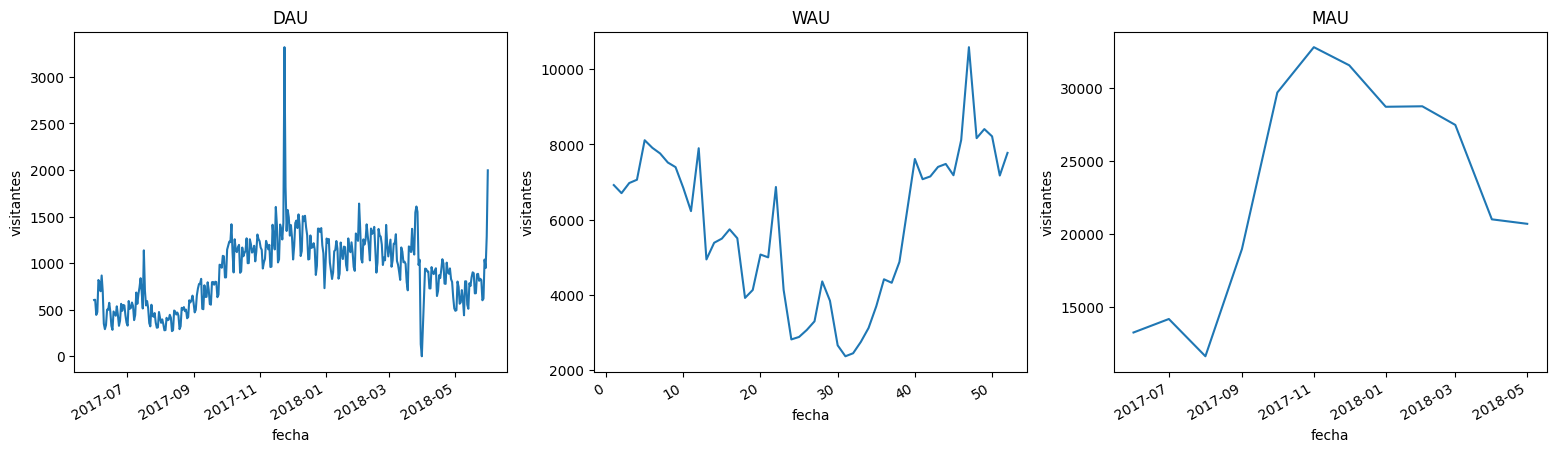

In [815]:
fig, ax = plt.subplots(1, 3, figsize=(19,5))
ax[0].plot(dau)
ax[0].set(title='DAU',xlabel='fecha',ylabel='visitantes')
ax[1].plot(wau)
ax[1].set(title='WAU',xlabel='fecha',ylabel='visitantes')
ax[2].plot(mau)
ax[2].set(title='MAU',xlabel='fecha',ylabel='visitantes')
fig.autofmt_xdate(rotation=30)
plt.show()

### Sesiones por día de cada usuario

In [816]:
#esto nos da hasta el día (omite información de la hora para abajo) pero es suficiente para lo que queremos hacer
sesiones_por_usuario = visitas.groupby('sesion_fecha').agg({'uid':['count', 'nunique']})

In [817]:
sesiones_por_usuario.columns = ['n_sesiones', 'n_usuarios']

In [818]:
sesiones_por_usuario['sesiones_por_usuario'] = (sesiones_por_usuario['n_sesiones']/sesiones_por_usuario['n_usuarios']).round(2)

In [819]:
sesiones_por_usuario

,n_sesiones,n_usuarios,sesiones_por_usuario
sesion_fecha,,,
2017-06-01,664,605,1.10
2017-06-02,658,608,1.08
2017-06-03,477,445,1.07
2017-06-04,510,476,1.07
2017-06-05,893,820,1.09
...,...,...,...
2018-05-27,672,620,1.08
2018-05-28,1156,1039,1.11
2018-05-29,1035,948,1.09


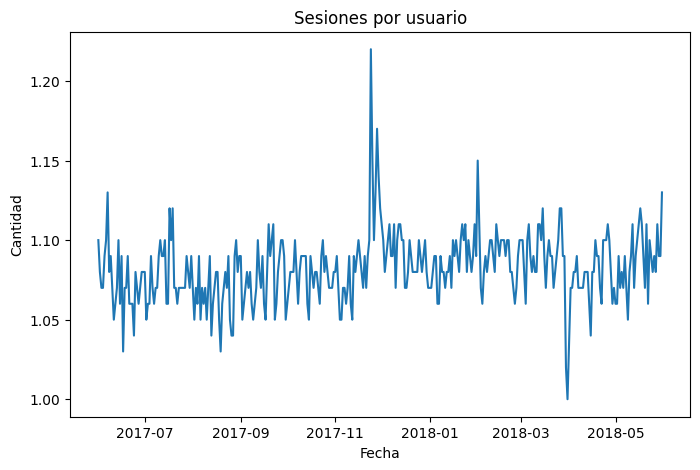

In [820]:
plt.figure(figsize=(8, 5))
plt.plot(sesiones_por_usuario['sesiones_por_usuario'])
plt.title('Sesiones por usuario')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.show()

### Duración de cada sesión

Para obtener la duración hay que restar el start_ts de end_ts.

In [821]:
visitas['duracion_visita'] = visitas['end_ts']-visitas['start_ts']

In [822]:
visitas.head()

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita
0,0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20,0 days 00:18:00
1,1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19,0 days 00:28:00
2,2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01,0 days 00:00:00
3,3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20,0 days 00:24:00
4,4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27,0 days 00:00:00


Podemos ver que todo dice 0 days lo que hace que se vea feo. Veamos si hay alguna que que llegue a 1 day. Si es que no, tambien veremos si hay una que llegue a la hora.

In [823]:
visitas[visitas['duracion_visita'] >= pd.Timedelta('1D')]

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita


No hay ninguna sesión que dure 1 día o más.

In [824]:
visitas[visitas['duracion_visita'] >= pd.Timedelta('1h')]

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita
15,15,touch,2018-02-12 20:30:00,2,2018-02-12 19:24:00,18188358787673499603,2018-02-01,7,2018-02-12,0 days 01:06:00
19,19,desktop,2018-05-17 19:26:00,2,2018-05-17 18:10:00,14243397340327062268,2018-05-01,20,2018-05-17,0 days 01:16:00
201,201,desktop,2017-06-29 12:19:00,2,2017-06-29 10:40:00,13888745432979765063,2017-06-01,26,2017-06-29,0 days 01:39:00
300,300,desktop,2018-01-30 16:07:00,3,2018-01-30 15:02:00,3886599060080125793,2018-01-01,5,2018-01-30,0 days 01:05:00
420,420,desktop,2017-10-09 20:08:00,3,2017-10-09 18:57:00,1786694324269537179,2017-10-01,41,2017-10-09,0 days 01:11:00
...,...,...,...,...,...,...,...,...,...,...
358399,358399,desktop,2017-07-20 20:08:00,1,2017-07-20 17:31:00,9534697107484505257,2017-07-01,29,2017-07-20,0 days 02:37:00
358424,358424,desktop,2018-01-16 11:08:00,1,2018-01-16 10:01:00,15283214588823731332,2018-01-01,3,2018-01-16,0 days 01:07:00
358429,358429,desktop,2017-08-23 08:29:00,2,2017-08-23 07:29:00,15847364094518434857,2017-08-01,34,2017-08-23,0 days 01:00:00
358433,358433,touch,2017-12-17 16:56:00,2,2017-12-17 15:09:00,11668998529606949896,2017-12-01,50,2017-12-17,0 days 01:47:00


Vemos que también hay horas.

In [825]:
visitas[(visitas['duracion_visita'] < pd.Timedelta('1m')) & (visitas['duracion_visita'] >= pd.Timedelta('1s'))] 

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita
358532,358532,desktop,2017-11-24 10:14:19,5,2017-11-24 10:14:00,2551852515556206,2017-11-01,47,2017-11-24,0 days 00:00:19
358533,358533,touch,2018-01-26 19:14:19,1,2018-01-26 19:14:00,21801295586117262,2018-01-01,4,2018-01-26,0 days 00:00:19
358534,358534,desktop,2017-07-14 15:43:19,1,2017-07-14 15:43:00,45173250638993302,2017-07-01,28,2017-07-14,0 days 00:00:19
358535,358535,touch,2017-10-04 12:51:19,4,2017-10-04 12:51:00,74720860360798980,2017-10-01,40,2017-10-04,0 days 00:00:19
358536,358536,desktop,2018-03-25 16:00:19,9,2018-03-25 16:00:00,86768018446815478,2018-03-01,12,2018-03-25,0 days 00:00:19
...,...,...,...,...,...,...,...,...,...,...
359395,359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-01,30,2017-07-29,0 days 00:00:19
359396,359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-01,4,2018-01-25,0 days 00:00:19
359397,359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-01,9,2018-03-03,0 days 00:00:19
359398,359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-01,44,2017-11-02,0 days 00:00:19


Vemos que también hay sesiones con duración en segundos.

### Frecuencia de retorno

In [826]:
#hay que ordenar para que el resultado no nos de negativo
visitas = visitas.sort_values(by=['uid', 'start_ts'])
visitas['tiempo_entre_visitas'] = visitas.groupby('uid')['start_ts'].diff()

In [827]:
visitas[~visitas['tiempo_entre_visitas'].isna()].sort_values(['uid'])


,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas
192554,192554,desktop,2018-02-18 15:26:00,2,2018-02-18 15:17:00,313578113262317,2018-02-01,7,2018-02-18,0 days 00:09:00,152 days 16:28:00
113873,113873,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,313578113262317,2018-03-01,10,2018-03-11,0 days 00:06:00,21 days 02:06:00
41778,41778,desktop,2018-02-26 12:34:00,5,2018-02-26 12:33:00,325320750514679,2018-02-01,9,2018-02-26,0 days 00:01:00,148 days 22:04:00
141543,141543,desktop,2017-10-21 21:44:00,2,2017-10-21 20:52:00,526778907996220,2017-10-01,42,2017-10-21,0 days 00:52:00,0 days 03:01:00
130654,130654,desktop,2018-01-08 11:37:00,2,2018-01-08 11:34:00,526778907996220,2018-01-01,2,2018-01-08,0 days 00:03:00,78 days 14:42:00
...,...,...,...,...,...,...,...,...,...,...,...
265059,265059,touch,2018-02-19 11:26:00,1,2018-02-19 10:17:00,18446156210226471712,2018-02-01,8,2018-02-19,0 days 01:09:00,4 days 13:12:00
97867,97867,desktop,2018-02-20 13:24:00,1,2018-02-20 12:47:00,18446156210226471712,2018-02-01,8,2018-02-20,0 days 00:37:00,1 days 02:30:00
247710,247710,desktop,2018-02-24 09:37:00,4,2018-02-24 09:36:00,18446156210226471712,2018-02-01,8,2018-02-24,0 days 00:01:00,3 days 20:49:00
254352,254352,desktop,2017-10-17 10:17:00,5,2017-10-17 10:12:00,18446167067214817906,2017-10-01,42,2017-10-17,0 days 00:05:00,0 days 00:07:00


Ahora que tenemos el tiempo entre visitas, tenemos que sacar un promedio para obtener la frecuencia.

In [828]:
frecuencia_retorno = (
    visitas.groupby('uid')['tiempo_entre_visitas']
    .mean()
    .reset_index()
    .rename(columns={'tiempo_entre_visitas': 'frecuencia_promedio'})
)

In [829]:
frecuencia_retorno[~frecuencia_retorno['frecuencia_promedio'].isna()]

,uid,frecuencia_promedio
3,313578113262317,86 days 21:17:00
4,325320750514679,148 days 22:04:00
8,526778907996220,55 days 22:11:40
9,577434573913691,6 days 03:53:00
16,1260655184775459,43 days 07:48:00
...,...,...
228154,18445884613277162497,25 days 12:18:00
228159,18446104389491815722,0 days 15:07:00
228161,18446156210226471712,18 days 03:55:50
228162,18446167067214817906,0 days 00:07:00


Los valores na representan gente que solo han iniciado sesión en 1 ocasión. Tenemos la frecuencia promedio por usuario, veamos la total.

In [830]:
frecuencia_retorno['frecuencia_promedio'].mean()

Timedelta('41 days 02:50:10.661332288')

En promedio un usuario vuelve a ingresar cada 41 días.

## Ventas

### Tiempo entre registro y conversión

In [831]:
visitas = visitas.sort_values(by=['uid', 'start_ts'],ascending=True)
visitas['primera_visita'] = visitas.groupby('uid')['start_ts'].transform('first')


In [832]:
visitas.sort_values('uid').head(10)

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita
196543,196543,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,11863502262781,2018-03-01,9,2018-03-01,0 days 00:06:00,NaT,2018-03-01 17:27:00
257333,257333,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,49537067089222,2018-02-01,6,2018-02-06,0 days 00:02:00,NaT,2018-02-06 15:55:00
173818,173818,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,297729379853735,2017-06-01,23,2017-06-07,0 days 00:01:00,NaT,2017-06-07 18:47:00
173142,173142,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,313578113262317,2017-09-01,38,2017-09-18,0 days 00:18:00,NaT,2017-09-18 22:49:00
192554,192554,desktop,2018-02-18 15:26:00,2,2018-02-18 15:17:00,313578113262317,2018-02-01,7,2018-02-18,0 days 00:09:00,152 days 16:28:00,2017-09-18 22:49:00
113873,113873,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,313578113262317,2018-03-01,10,2018-03-11,0 days 00:06:00,21 days 02:06:00,2017-09-18 22:49:00
34588,34588,desktop,2017-09-30 14:38:00,5,2017-09-30 14:29:00,325320750514679,2017-09-01,39,2017-09-30,0 days 00:09:00,NaT,2017-09-30 14:29:00
41778,41778,desktop,2018-02-26 12:34:00,5,2018-02-26 12:33:00,325320750514679,2018-02-01,9,2018-02-26,0 days 00:01:00,148 days 22:04:00,2017-09-30 14:29:00
188450,188450,touch,2018-01-18 12:33:00,4,2018-01-18 12:32:00,397399764396656,2018-01-01,3,2018-01-18,0 days 00:01:00,NaT,2018-01-18 12:32:00
183750,183750,desktop,2017-06-17 13:45:00,2,2017-06-17 13:40:00,407573351275847,2017-06-01,24,2017-06-17,0 days 00:05:00,NaT,2017-06-17 13:40:00


Tenemos la primera vez que ingresaron. Ahora tenemos que obtener la primera vez que compraron.

In [833]:
ordenes = orders.sort_values(by=['uid', 'buy_ts'],ascending=True)
ordenes['primera_compra'] = ordenes.groupby('uid')['buy_ts'].transform('first')


In [834]:
ordenes

,buy_ts,revenue,uid,primera_compra
27944,2018-01-03 21:51:00,0.55,313578113262317,2018-01-03 21:51:00
213,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00
252,2017-06-03 17:39:00,1.83,1575281904278712,2017-06-03 10:13:00
12235,2017-10-11 18:33:00,73.33,2429014661409475,2017-10-11 18:33:00
31462,2018-01-28 15:54:00,2.44,2464366381792757,2018-01-28 15:54:00
...,...,...,...,...
8919,2017-09-24 23:48:00,0.24,18445407535914413204,2017-09-22 23:55:00
9023,2017-09-25 15:56:00,0.12,18445407535914413204,2017-09-22 23:55:00
42213,2018-03-26 22:54:00,4.22,18445601152732270159,2018-03-26 22:54:00
35572,2018-02-18 19:34:00,9.78,18446156210226471712,2018-02-18 19:34:00


In [835]:
visitas['uid'].nunique()

228169

Perfecto, ahora tenemos que unir las tablas y obtener la diferencia entre el tiempo de la primera visita y de la primera compra. Hagamos que no hayan usuarios repetidos

In [836]:
visitas

,Unnamed: 0,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita
196543,196543,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,11863502262781,2018-03-01,9,2018-03-01,0 days 00:06:00,NaT,2018-03-01 17:27:00
257333,257333,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,49537067089222,2018-02-01,6,2018-02-06,0 days 00:02:00,NaT,2018-02-06 15:55:00
173818,173818,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,297729379853735,2017-06-01,23,2017-06-07,0 days 00:01:00,NaT,2017-06-07 18:47:00
173142,173142,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,313578113262317,2017-09-01,38,2017-09-18,0 days 00:18:00,NaT,2017-09-18 22:49:00
192554,192554,desktop,2018-02-18 15:26:00,2,2018-02-18 15:17:00,313578113262317,2018-02-01,7,2018-02-18,0 days 00:09:00,152 days 16:28:00,2017-09-18 22:49:00
...,...,...,...,...,...,...,...,...,...,...,...,...
175259,175259,touch,2017-12-06 20:32:00,4,2017-12-06 20:32:00,18446424184725333426,2017-12-01,49,2017-12-06,0 days 00:00:00,NaT,2017-12-06 20:32:00
293449,293449,touch,2018-01-01 16:31:00,3,2018-01-01 16:29:00,18446556406699109058,2018-01-01,1,2018-01-01,0 days 00:02:00,NaT,2018-01-01 16:29:00
319162,319162,desktop,2017-12-27 14:08:00,4,2017-12-27 13:27:00,18446621818809592527,2017-12-01,52,2017-12-27,0 days 00:41:00,NaT,2017-12-27 13:27:00
222173,222173,desktop,2018-05-21 09:45:00,4,2018-05-21 09:30:00,18446621818809592527,2018-05-01,21,2018-05-21,0 days 00:15:00,144 days 20:03:00,2017-12-27 13:27:00


In [837]:
vis_2 = visitas.groupby('uid')
# vis_ord_2 = ord_2.merge(visitas,on='uid',how='inner')

In [838]:
vis_ord_prev = ordenes.merge(visitas,on='uid',how='inner')
#esto nos da todas las compras varias veces
vis_ord = vis_ord_prev[(vis_ord_prev['buy_ts'] >= vis_ord_prev['start_ts']) & (vis_ord_prev['buy_ts'] <= vis_ord_prev['end_ts'])]
#no todas las sesiones resultan en una compra

In [839]:
vis_ord

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita
3,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,357823,touch,2017-06-03 10:17:00,10,2017-06-03 10:13:00,2017-06-01,22,2017-06-03,0 days 00:04:00,NaT,2017-06-03 10:13:00
6,2017-06-03 17:39:00,1.83,1575281904278712,2017-06-03 10:13:00,357999,touch,2017-06-03 17:48:00,10,2017-06-03 17:36:00,2017-06-01,22,2017-06-03,0 days 00:12:00,0 days 07:23:00,2017-06-03 10:13:00
10,2017-11-24 10:14:00,6.32,2551852515556206,2017-11-24 10:14:00,358532,desktop,2017-11-24 10:14:19,5,2017-11-24 10:14:00,2017-11-01,47,2017-11-24,0 days 00:00:19,NaT,2017-11-24 10:14:00
13,2017-11-24 11:24:00,4.67,2551852515556206,2017-11-24 10:14:00,92564,desktop,2017-11-24 11:31:00,5,2017-11-24 11:22:00,2017-11-01,47,2017-11-24,0 days 00:09:00,0 days 01:08:00,2017-11-24 10:14:00
14,2018-03-03 12:33:00,4.67,3077748354309989,2018-03-03 12:33:00,196600,touch,2018-03-03 12:38:00,3,2018-03-03 12:08:00,2018-03-01,9,2018-03-03,0 days 00:30:00,NaT,2018-03-03 12:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761784,2018-02-05 19:39:00,0.18,18442290965339407211,2018-02-05 19:39:00,130291,touch,2018-02-05 19:58:00,3,2018-02-05 19:35:00,2018-02-01,6,2018-02-05,0 days 00:23:00,NaT,2018-02-05 19:35:00
761786,2017-09-22 23:55:00,0.52,18445407535914413204,2017-09-22 23:55:00,56314,desktop,2017-09-22 23:55:00,3,2017-09-22 23:48:00,2017-09-01,38,2017-09-22,0 days 00:07:00,NaT,2017-09-22 23:48:00
761790,2017-09-24 23:48:00,0.24,18445407535914413204,2017-09-22 23:55:00,160902,touch,2017-09-25 00:14:00,3,2017-09-24 23:34:00,2017-09-01,38,2017-09-24,0 days 00:40:00,1 days 23:46:00,2017-09-22 23:48:00
761797,2018-03-26 22:54:00,4.22,18445601152732270159,2018-03-26 22:54:00,4586,desktop,2018-03-26 23:32:00,2,2018-03-26 21:04:00,2018-03-01,13,2018-03-26,0 days 02:28:00,167 days 02:48:00,2017-08-07 11:51:00


Es interesante ver que no todas las ordenes caen dentro del rango de la sesión.

In [840]:
vis_ord = vis_ord.sort_values(by=['uid', 'start_ts'])

vis_ord_no_dup = vis_ord.drop_duplicates(subset='uid', keep='first').copy()

In [841]:
vis_ord_no_dup['tiempo_registro_compra'] = vis_ord_no_dup['primera_compra']-vis_ord_no_dup['primera_visita']

In [842]:
vis_ord_no_dup.iloc[:,-1]

3          0 days 00:00:00
10         0 days 00:00:00
14         0 days 00:25:00
16        36 days 23:02:00
61         0 days 00:22:00
                ...       
761783    39 days 23:55:00
761784     0 days 00:04:00
761786     0 days 00:07:00
761797   231 days 11:03:00
761806     0 days 00:11:00
Name: tiempo_registro_compra, Length: 29794, dtype: timedelta64[ns]

In [843]:
vis_ord_no_dup = vis_ord_no_dup.sort_values(by='tiempo_registro_compra')

In [844]:
vis_ord_no_dup

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita,tiempo_registro_compra
3,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,357823,touch,2017-06-03 10:17:00,10,2017-06-03 10:13:00,2017-06-01,22,2017-06-03,0 days 00:04:00,NaT,2017-06-03 10:13:00,0 days 00:00:00
613823,2018-01-23 12:50:00,1.10,12033446639148843439,2018-01-23 12:50:00,359093,touch,2018-01-23 12:50:19,1,2018-01-23 12:50:00,2018-01-01,4,2018-01-23,0 days 00:00:19,NaT,2018-01-23 12:50:00,0 days 00:00:00
613800,2017-07-01 22:22:00,1.22,12023867455503191367,2017-07-01 22:22:00,138334,desktop,2017-07-01 22:25:00,3,2017-07-01 22:22:00,2017-07-01,26,2017-07-01,0 days 00:03:00,NaT,2017-07-01 22:22:00,0 days 00:00:00
613793,2017-12-14 10:55:00,0.06,12023015942585151053,2017-12-14 10:55:00,359092,touch,2017-12-14 10:55:19,1,2017-12-14 10:55:00,2017-12-01,50,2017-12-14,0 days 00:00:19,NaT,2017-12-14 10:55:00,0 days 00:00:00
613792,2018-01-06 12:52:00,1.22,12021893543482118358,2018-01-06 12:52:00,13953,desktop,2018-01-06 12:53:00,4,2018-01-06 12:52:00,2018-01-01,1,2018-01-06,0 days 00:01:00,NaT,2018-01-06 12:52:00,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734670,2018-05-28 11:03:00,0.85,16265474504222300952,2018-05-28 11:03:00,262257,desktop,2018-05-28 11:05:00,5,2018-05-28 11:01:00,2018-05-01,22,2018-05-28,0 days 00:04:00,354 days 21:46:00,2017-06-07 13:15:00,354 days 21:48:00
317518,2018-05-28 15:02:00,1.83,6158008917228642735,2018-05-28 15:02:00,46376,desktop,2018-05-28 15:03:00,3,2018-05-28 15:00:00,2018-05-01,22,2018-05-28,0 days 00:03:00,355 days 18:05:00,2017-06-06 20:55:00,355 days 18:07:00
315520,2018-05-28 19:15:00,0.92,6079087450327100134,2018-05-28 19:15:00,314554,desktop,2018-05-28 19:33:00,10,2018-05-28 19:09:00,2018-05-01,22,2018-05-28,0 days 00:24:00,0 days 07:19:00,2017-06-05 18:05:00,357 days 01:10:00
616213,2018-05-29 21:51:00,0.24,12282157960125853781,2018-05-29 21:51:00,98802,touch,2018-05-29 21:58:00,3,2018-05-29 21:47:00,2018-05-01,22,2018-05-29,0 days 00:11:00,354 days 04:33:00,2017-06-06 14:20:00,357 days 07:31:00


La gente que tiene 0 en todo aún no han realizado una compra. No hay compras con diferencia de 1 año.

In [936]:
import seaborn as sns

In [937]:
#definiendo una funcion para el kpi
def plot_kpi(kpi_series, title="Evolución del KPI", ylabel="Valor", xlabel="Fecha"):
    plt.figure(figsize=(10, 4))
    kpi_series.plot(marker='o')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('../reports/figures/kpi.png', dpi=300)
    plt.show()

In [931]:
vis_ord_no_dup['sesion_fecha'] = pd.to_datetime(vis_ord_no_dup['sesion_fecha'])
vis_ord_sorted = vis_ord_no_dup.sort_values('sesion_fecha')
kpi_series = vis_ord_sorted.set_index('sesion_fecha').iloc[:, -1]  # última columna con sesion_fecha como índice


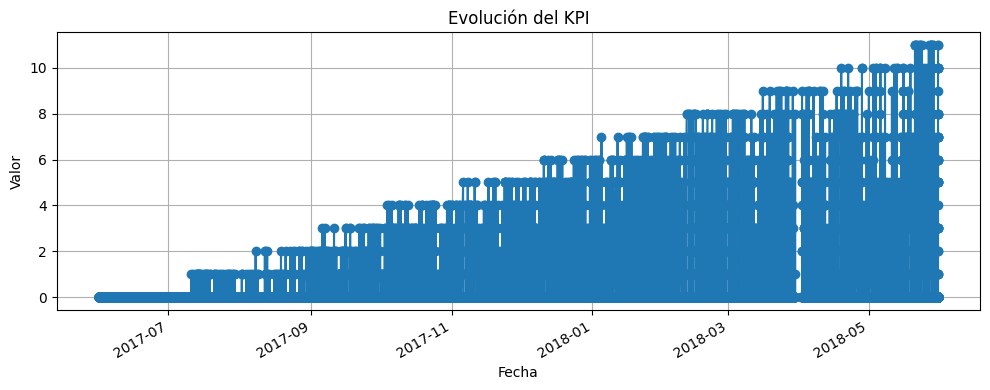

In [934]:
plot_kpi(kpi_series)


In [845]:
vis_ord_no_dup.iloc[:,-1].mean()

Timedelta('11 days 16:14:46.966503322')

El promedio entre el registro y una compra es de casi 12 días.

Ahora, hagamos los dividamos en tiempo.

In [846]:
vis_ord_no_dup['conversion_dia'] = vis_ord_no_dup['tiempo_registro_compra'].dt.days
vis_ord_no_dup['conversion_mes'] = (vis_ord_no_dup['tiempo_registro_compra'].dt.days)//31

In [847]:
vis_ord_no_dup

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita,tiempo_registro_compra,conversion_dia,conversion_mes
3,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,357823,touch,2017-06-03 10:17:00,10,2017-06-03 10:13:00,2017-06-01,22,2017-06-03,0 days 00:04:00,NaT,2017-06-03 10:13:00,0 days 00:00:00,0,0
613823,2018-01-23 12:50:00,1.10,12033446639148843439,2018-01-23 12:50:00,359093,touch,2018-01-23 12:50:19,1,2018-01-23 12:50:00,2018-01-01,4,2018-01-23,0 days 00:00:19,NaT,2018-01-23 12:50:00,0 days 00:00:00,0,0
613800,2017-07-01 22:22:00,1.22,12023867455503191367,2017-07-01 22:22:00,138334,desktop,2017-07-01 22:25:00,3,2017-07-01 22:22:00,2017-07-01,26,2017-07-01,0 days 00:03:00,NaT,2017-07-01 22:22:00,0 days 00:00:00,0,0
613793,2017-12-14 10:55:00,0.06,12023015942585151053,2017-12-14 10:55:00,359092,touch,2017-12-14 10:55:19,1,2017-12-14 10:55:00,2017-12-01,50,2017-12-14,0 days 00:00:19,NaT,2017-12-14 10:55:00,0 days 00:00:00,0,0
613792,2018-01-06 12:52:00,1.22,12021893543482118358,2018-01-06 12:52:00,13953,desktop,2018-01-06 12:53:00,4,2018-01-06 12:52:00,2018-01-01,1,2018-01-06,0 days 00:01:00,NaT,2018-01-06 12:52:00,0 days 00:00:00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734670,2018-05-28 11:03:00,0.85,16265474504222300952,2018-05-28 11:03:00,262257,desktop,2018-05-28 11:05:00,5,2018-05-28 11:01:00,2018-05-01,22,2018-05-28,0 days 00:04:00,354 days 21:46:00,2017-06-07 13:15:00,354 days 21:48:00,354,11
317518,2018-05-28 15:02:00,1.83,6158008917228642735,2018-05-28 15:02:00,46376,desktop,2018-05-28 15:03:00,3,2018-05-28 15:00:00,2018-05-01,22,2018-05-28,0 days 00:03:00,355 days 18:05:00,2017-06-06 20:55:00,355 days 18:07:00,355,11
315520,2018-05-28 19:15:00,0.92,6079087450327100134,2018-05-28 19:15:00,314554,desktop,2018-05-28 19:33:00,10,2018-05-28 19:09:00,2018-05-01,22,2018-05-28,0 days 00:24:00,0 days 07:19:00,2017-06-05 18:05:00,357 days 01:10:00,357,11
616213,2018-05-29 21:51:00,0.24,12282157960125853781,2018-05-29 21:51:00,98802,touch,2018-05-29 21:58:00,3,2018-05-29 21:47:00,2018-05-01,22,2018-05-29,0 days 00:11:00,354 days 04:33:00,2017-06-06 14:20:00,357 days 07:31:00,357,11


Perfecto

### Pedidos durante un periodo de tiempo

In [848]:
ordenes['compra_cohorte_dia'] = ordenes['buy_ts'].dt.date
ordenes['compra_cohorte_mes'] = ordenes['buy_ts'].dt.to_period('M')
ordenes['compra_cohorte_year'] = ordenes['buy_ts'].dt.year

In [849]:
#usamos size ya que se ve más limpio. Al usar count se hace un conteo para cada columna
print('\nPedidos diarios\n')
print(ordenes.groupby('compra_cohorte_dia').size())
print('\n\n\nPedidos mensuales\n')
print(ordenes.groupby('compra_cohorte_mes').size())
print('\n\n\nPedidos anuales\n')
print(ordenes.groupby('compra_cohorte_year').size())



Pedidos diarios

compra_cohorte_dia
2017-06-01     96
2017-06-02    111
2017-06-03     67
2017-06-04     66
2017-06-05    161
             ... 
2018-05-28    188
2018-05-29    189
2018-05-30    208
2018-05-31    610
2018-06-01      1
Length: 364, dtype: int64



Pedidos mensuales

compra_cohorte_mes
2017-06    2354
2017-07    2363
2017-08    1807
2017-09    3387
2017-10    5679
2017-11    5659
2017-12    6218
2018-01    4721
2018-02    5281
2018-03    5326
2018-04    3273
2018-05    4346
2018-06       1
Freq: M, dtype: int64



Pedidos anuales

compra_cohorte_year
2017    27467
2018    22948
dtype: int64


Tambien podemos sacar la hora para saber en que hora se realizan más pedidos. Para esto me parece no tan útil mantener día. Quizá mantener mes sería interesante para entender temporalidad.

In [850]:
ordenes['cohorte_hora_del_dia'] = ordenes['buy_ts'].dt.hour

ordenes['compra_cohorte_hora_mes'] = ordenes['buy_ts'].dt.strftime('%m %H:00')

ordenes['compra_cohorte_hora_mes_dia'] = ordenes['buy_ts'].dt.strftime('%m-%d %H:00')

ordenes['compra_cohorte_hora_year_mes_dia'] = ordenes['buy_ts'].dt.to_period('h')

In [851]:
print('\nPedidos por hora\n')
print(ordenes.groupby('cohorte_hora_del_dia').size())
print('\n\n\nPedidos por mes y hora\n')
print(ordenes.groupby('compra_cohorte_hora_mes').size())
print('\n\n\nPedidos por mes, día y hora\n')
print(ordenes.groupby('compra_cohorte_hora_mes_dia').size())
print('\n\n\nPedidos por mes, día, año y hora\n')
print(ordenes.groupby('compra_cohorte_hora_year_mes_dia').size())


Pedidos por hora

cohorte_hora_del_dia
0     1354
1      669
2      305
3      150
4       74
5       81
6      156
7      347
8      840
9     1972
10    3193
11    3757
12    3958
13    3911
14    3588
15    3374
16    3294
17    3174
18    2774
19    2551
20    2846
21    2959
22    2943
23    2145
dtype: int64



Pedidos por mes y hora

compra_cohorte_hora_mes
01 00:00    139
01 01:00     73
01 02:00     39
01 03:00     18
01 04:00      5
           ... 
12 19:00    325
12 20:00    358
12 21:00    357
12 22:00    349
12 23:00    281
Length: 288, dtype: int64



Pedidos por mes, día y hora

compra_cohorte_hora_mes_dia
01-01 00:00     2
01-01 01:00     2
01-01 02:00     1
01-01 04:00     1
01-01 06:00     1
               ..
12-31 19:00    13
12-31 20:00     9
12-31 21:00    12
12-31 22:00     7
12-31 23:00     5
Length: 6985, dtype: int64



Pedidos por mes, día, año y hora

compra_cohorte_hora_year_mes_dia
2017-06-01 00:00     4
2017-06-01 07:00     1
2017-06-01 08:00     2
2017-0

Listo, tenemos suficientes divisiones para pedidos en un periodo de tiempo.

### Ticket promedio

In [852]:
ordenes['revenue'].mean().round(4)

4.9996

El ticket promedio tiene un valor de casi 5$. Este valor debe de cambiar para cada periodo.

In [853]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50415 entries, 27944 to 13176
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   buy_ts                            50415 non-null  datetime64[ns]
 1   revenue                           50415 non-null  float64       
 2   uid                               50415 non-null  uint64        
 3   primera_compra                    50415 non-null  datetime64[ns]
 4   compra_cohorte_dia                50415 non-null  object        
 5   compra_cohorte_mes                50415 non-null  period[M]     
 6   compra_cohorte_year               50415 non-null  int32         
 7   cohorte_hora_del_dia              50415 non-null  int32         
 8   compra_cohorte_hora_mes           50415 non-null  object        
 9   compra_cohorte_hora_mes_dia       50415 non-null  object        
 10  compra_cohorte_hora_year_mes_dia  50415 non-nul

In [854]:
for i in range(4,11):
    print('\n\n\n\n')
    print(ordenes.groupby(ordenes.iloc[:,i])['revenue'].mean().round(2).sort_values(ascending=False))






compra_cohorte_dia
2017-12-10    29.13
2017-06-14    13.40
2018-02-24    13.33
2017-12-17    12.92
2018-03-18    11.27
              ...  
2018-05-29     2.60
2017-06-03     2.48
2017-06-07     2.47
2017-06-08     2.45
2018-03-30     1.95
Name: revenue, Length: 364, dtype: float64





compra_cohorte_mes
2017-12    5.85
2017-09    5.42
2018-03    5.41
2017-07    5.31
2018-04    5.15
2017-10    4.93
2017-08    4.85
2018-02    4.84
2017-11    4.78
2018-05    4.77
2018-01    4.11
2017-06    4.06
2018-06    3.42
Freq: M, Name: revenue, dtype: float64





compra_cohorte_year
2017    5.12
2018    4.85
Name: revenue, dtype: float64





cohorte_hora_del_dia
8     5.81
19    5.76
18    5.70
20    5.53
9     5.53
13    5.22
7     5.15
12    5.02
15    5.02
11    5.01
16    4.93
17    4.91
10    4.72
23    4.70
2     4.68
14    4.56
5     4.56
21    4.53
0     4.53
1     4.50
22    4.39
6     4.25
3     4.20
4     3.63
Name: revenue, dtype: float64





compra_cohorte_hora_mes
02 08:00    

Es evidente que meses como Febrero o Diciembre tienen un gran impacto en las ventas. Las 8 am es la hora donde mas se ingresa.

### LTV por cohorte

Como cohorte vamos a seleccionar la fecha de registro.

In [855]:
vis_ord.groupby('primera_visita')['revenue'].mean().round(2).sort_values(ascending=False)

primera_visita
2017-12-17 18:00:00    640.71
2017-06-14 13:39:00    407.00
2017-09-26 22:35:00    275.74
2017-11-07 18:22:00    201.67
2017-10-24 21:57:00    195.55
                        ...  
2017-12-04 22:06:00      0.00
2018-05-26 12:12:00      0.00
2017-12-01 12:11:00      0.00
2017-11-28 20:58:00      0.00
2017-11-30 20:17:00      0.00
Name: revenue, Length: 28325, dtype: float64

Para poder visualizar mejor voy a hacer un mapa de calor para primera visita mes y dia. Este tiene demasiada informacón.

In [856]:
vis_ord['primera_visita_dia'] = pd.to_datetime(vis_ord['primera_visita'].dt.date)
vis_ord['primera_visita_mes'] = pd.to_datetime(vis_ord['primera_visita'].dt.strftime('%Y-%m-01'))

In [857]:
vis_ord.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35927 entries, 3 to 761806
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   buy_ts                35927 non-null  datetime64[ns] 
 1   revenue               35927 non-null  float64        
 2   uid                   35927 non-null  uint64         
 3   primera_compra        35927 non-null  datetime64[ns] 
 4   Unnamed: 0            35927 non-null  int64          
 5   device                35927 non-null  object         
 6   end_ts                35927 non-null  datetime64[ns] 
 7   source_id             35927 non-null  int64          
 8   start_ts              35927 non-null  datetime64[ns] 
 9   sesion_mes            35927 non-null  datetime64[ns] 
 10  sesion_semana         35927 non-null  UInt32         
 11  sesion_fecha          35927 non-null  object         
 12  duracion_visita       35927 non-null  timedelta64[ns]
 13  tiemp

In [858]:
import numpy as np

In [859]:
cohortes_para_ltv = vis_ord.groupby('uid')['primera_visita_mes'].first()

In [860]:
vis_ord.sort_values('uid')

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita,primera_visita_dia,primera_visita_mes
3,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,357823,touch,2017-06-03 10:17:00,10,2017-06-03 10:13:00,2017-06-01,22,2017-06-03,0 days 00:04:00,NaT,2017-06-03 10:13:00,2017-06-03,2017-06-01
6,2017-06-03 17:39:00,1.83,1575281904278712,2017-06-03 10:13:00,357999,touch,2017-06-03 17:48:00,10,2017-06-03 17:36:00,2017-06-01,22,2017-06-03,0 days 00:12:00,0 days 07:23:00,2017-06-03 10:13:00,2017-06-03,2017-06-01
10,2017-11-24 10:14:00,6.32,2551852515556206,2017-11-24 10:14:00,358532,desktop,2017-11-24 10:14:19,5,2017-11-24 10:14:00,2017-11-01,47,2017-11-24,0 days 00:00:19,NaT,2017-11-24 10:14:00,2017-11-24,2017-11-01
13,2017-11-24 11:24:00,4.67,2551852515556206,2017-11-24 10:14:00,92564,desktop,2017-11-24 11:31:00,5,2017-11-24 11:22:00,2017-11-01,47,2017-11-24,0 days 00:09:00,0 days 01:08:00,2017-11-24 10:14:00,2017-11-24,2017-11-01
14,2018-03-03 12:33:00,4.67,3077748354309989,2018-03-03 12:33:00,196600,touch,2018-03-03 12:38:00,3,2018-03-03 12:08:00,2018-03-01,9,2018-03-03,0 days 00:30:00,NaT,2018-03-03 12:08:00,2018-03-03,2018-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761784,2018-02-05 19:39:00,0.18,18442290965339407211,2018-02-05 19:39:00,130291,touch,2018-02-05 19:58:00,3,2018-02-05 19:35:00,2018-02-01,6,2018-02-05,0 days 00:23:00,NaT,2018-02-05 19:35:00,2018-02-05,2018-02-01
761786,2017-09-22 23:55:00,0.52,18445407535914413204,2017-09-22 23:55:00,56314,desktop,2017-09-22 23:55:00,3,2017-09-22 23:48:00,2017-09-01,38,2017-09-22,0 days 00:07:00,NaT,2017-09-22 23:48:00,2017-09-22,2017-09-01
761790,2017-09-24 23:48:00,0.24,18445407535914413204,2017-09-22 23:55:00,160902,touch,2017-09-25 00:14:00,3,2017-09-24 23:34:00,2017-09-01,38,2017-09-24,0 days 00:40:00,1 days 23:46:00,2017-09-22 23:48:00,2017-09-22,2017-09-01
761797,2018-03-26 22:54:00,4.22,18445601152732270159,2018-03-26 22:54:00,4586,desktop,2018-03-26 23:32:00,2,2018-03-26 21:04:00,2018-03-01,13,2018-03-26,0 days 02:28:00,167 days 02:48:00,2017-08-07 11:51:00,2017-08-07,2017-08-01


In [861]:
vis_ord['edad_meses']=((vis_ord['sesion_mes']-vis_ord['primera_visita_mes'])/(30*np.timedelta64(1,'D'))).round().astype('int')


In [862]:
(vis_ord['sesion_mes']-vis_ord['primera_visita_mes'])

3          0 days
6          0 days
10         0 days
13         0 days
14         0 days
           ...   
761784     0 days
761786     0 days
761790     0 days
761797   212 days
761806     0 days
Length: 35927, dtype: timedelta64[ns]

In [863]:
vis_ord.sort_values('uid').head(10)

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,sesion_semana,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita,primera_visita_dia,primera_visita_mes,edad_meses
3,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,357823,touch,2017-06-03 10:17:00,10,2017-06-03 10:13:00,2017-06-01,22,2017-06-03,0 days 00:04:00,NaT,2017-06-03 10:13:00,2017-06-03,2017-06-01,0
6,2017-06-03 17:39:00,1.83,1575281904278712,2017-06-03 10:13:00,357999,touch,2017-06-03 17:48:00,10,2017-06-03 17:36:00,2017-06-01,22,2017-06-03,0 days 00:12:00,0 days 07:23:00,2017-06-03 10:13:00,2017-06-03,2017-06-01,0
10,2017-11-24 10:14:00,6.32,2551852515556206,2017-11-24 10:14:00,358532,desktop,2017-11-24 10:14:19,5,2017-11-24 10:14:00,2017-11-01,47,2017-11-24,0 days 00:00:19,NaT,2017-11-24 10:14:00,2017-11-24,2017-11-01,0
13,2017-11-24 11:24:00,4.67,2551852515556206,2017-11-24 10:14:00,92564,desktop,2017-11-24 11:31:00,5,2017-11-24 11:22:00,2017-11-01,47,2017-11-24,0 days 00:09:00,0 days 01:08:00,2017-11-24 10:14:00,2017-11-24,2017-11-01,0
14,2018-03-03 12:33:00,4.67,3077748354309989,2018-03-03 12:33:00,196600,touch,2018-03-03 12:38:00,3,2018-03-03 12:08:00,2018-03-01,9,2018-03-03,0 days 00:30:00,NaT,2018-03-03 12:08:00,2018-03-03,2018-03-01,0
16,2017-09-21 20:56:00,0.12,3605148382144603,2017-09-21 20:56:00,328600,desktop,2017-09-21 21:22:00,2,2017-09-21 20:52:00,2017-09-01,38,2017-09-21,0 days 00:30:00,36 days 22:58:00,2017-08-15 21:54:00,2017-08-15,2017-08-01,1
47,2017-09-21 23:52:00,0.33,3605148382144603,2017-09-21 20:56:00,304622,desktop,2017-09-22 00:01:00,5,2017-09-21 22:52:00,2017-09-01,38,2017-09-21,0 days 01:09:00,0 days 02:00:00,2017-08-15 21:54:00,2017-08-15,2017-08-01,1
61,2018-01-09 23:32:00,1.22,4808417689019433,2018-01-09 23:32:00,51639,desktop,2018-01-09 23:33:00,4,2018-01-09 23:10:00,2018-01-01,2,2018-01-09,0 days 00:23:00,NaT,2018-01-09 23:10:00,2018-01-09,2018-01-01,0
62,2018-04-04 13:54:00,3.05,4992223027560440,2018-04-04 13:54:00,299408,touch,2018-04-04 13:56:00,5,2018-04-04 13:54:00,2018-04-01,14,2018-04-04,0 days 00:02:00,NaT,2018-04-04 13:54:00,2018-04-04,2018-04-01,0
65,2017-11-13 14:43:00,3.91,5081614443770358,2017-11-13 14:43:00,198124,desktop,2017-11-13 14:48:00,5,2017-11-13 14:33:00,2017-11-01,46,2017-11-13,0 days 00:15:00,0 days 00:14:00,2017-10-20 12:10:00,2017-10-20,2017-10-01,1


In [913]:
cohortes_ltv = vis_ord.pivot_table(
    index='primera_visita_mes',
    columns = 'edad_meses',
    values = 'revenue',
    aggfunc='mean'
)

In [865]:
cohortes_ltv

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_visita_mes,,,,,,,,,,,,
2017-06-01,3.934864,6.097005,4.959836,7.316651,6.174229,6.211442,7.180512,8.510500,5.673600,12.209935,11.749775,6.836296
2017-07-01,5.011527,6.065698,6.271075,5.187347,4.104239,4.886897,3.391081,4.985125,5.312840,6.181250,4.398627,NaN
2017-08-01,4.573218,4.309735,4.423900,5.390562,4.179101,4.071154,5.149091,6.084154,11.297778,4.240444,NaN,NaN
2017-09-01,4.812876,7.869470,6.273654,33.176596,12.808971,8.731146,3.987033,6.274250,4.522414,NaN,NaN,NaN
2017-10-01,4.227290,5.729895,3.622629,4.515481,4.372364,4.269083,3.244561,4.768971,NaN,NaN,NaN,NaN
2017-11-01,4.183999,3.221870,3.796465,4.630706,3.334857,5.196462,4.477442,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.266413,3.878000,12.701429,27.984364,4.426393,4.549875,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,3.547907,4.483659,5.444597,3.743061,3.409836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,3.573328,4.285291,7.277143,4.840656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import seaborn as sns

cohort_df.index = cohort_df.index.to_series().dt.strftime('%Y-%m-%d')

In [927]:
def plot_cohort_heatmap(cohort_df, title="Cohort Retention Heatmap"):

    plt.figure(figsize=(14, 6))
    sns.heatmap(cohort_df, annot=True, fmt=".1f", linewidth=1, linecolor='gray')
    plt.title(title)
    plt.ylabel("Primera visita")
    plt.xlabel("Edad (meses)")
    plt.tight_layout()
    plt.savefig('../reports/figures/heatmap_ltv.png', dpi=300)

    plt.show()


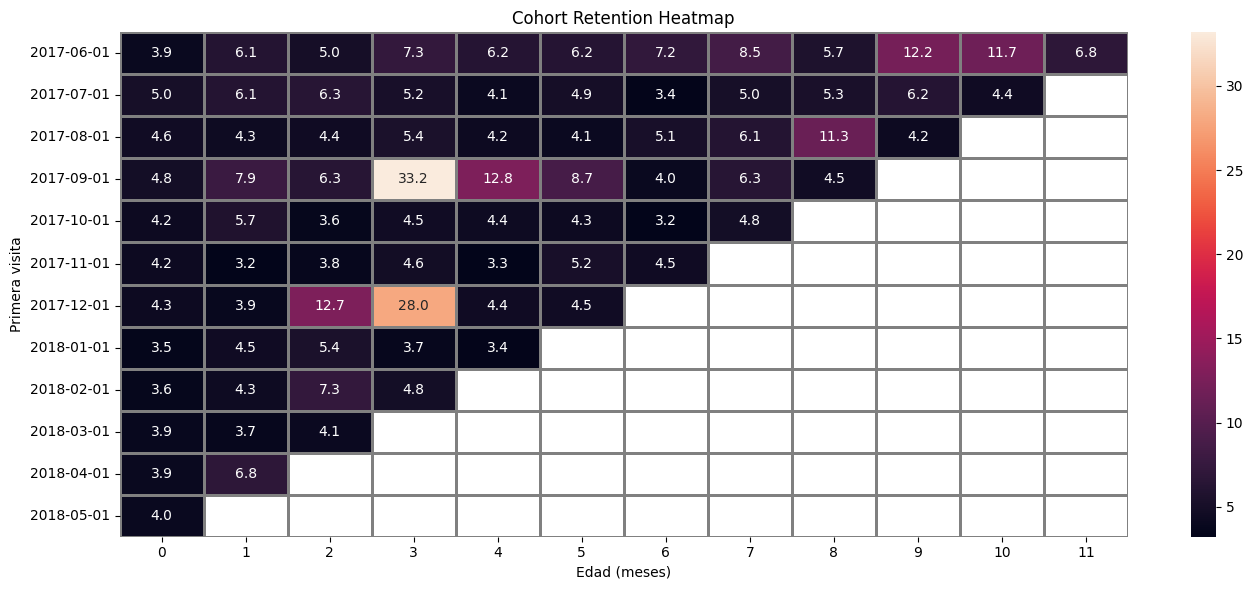

In [928]:
plot_cohort_heatmap(cohortes_ltv)

Algo sumamente interesante aparece. La gente que tuvo su primera compra en Septiembre gastan mas por mes que gente que inicio en otro mes. En particular en Diciembre, donde su gasto es el mayor de cualquier sección

## Marketing

### Gastos totales y por fuente a lo largo del tiempo

In [866]:
costs['costs'].sum()

329131.62

Los gastos totales en marketing fueron de 329131.62 $

In [867]:
costos.groupby('source_id')['costs'].sum()

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

La fuente en la que más se gastó fue la 3, con 141321.63 $

### CAC por fuente

Para calcular el CAC tenemos que seleccionar un periodo. El mes me parece correcto.

Hay aue obtener el numero de clientes por mes, usando la primera visita.

In [868]:
costos['dt_dia'] = pd.to_datetime(costos['dt'].dt.date)
costos['dt_mes'] = pd.to_datetime(costos['dt'].dt.strftime('%Y-%m-01'))

In [869]:
vis_ord.groupby('primera_visita_mes')['primera_visita_mes'].size()

primera_visita_mes
2017-06-01    3960
2017-07-01    2434
2017-08-01    1773
2017-09-01    2976
2017-10-01    4474
2017-11-01    4145
2017-12-01    3863
2018-01-01    2857
2018-02-01    2932
2018-03-01    2731
2018-04-01    1755
2018-05-01    2027
Name: primera_visita_mes, dtype: int64

In [870]:
costos[costos['source_id']==1].groupby('dt_mes')['costs'].sum()

dt_mes
2017-06-01    1125.61
2017-07-01    1072.88
2017-08-01     951.81
2017-09-01    1502.01
2017-10-01    2315.75
2017-11-01    2445.16
2017-12-01    2341.20
2018-01-01    2186.18
2018-02-01    2204.48
2018-03-01    1893.09
2018-04-01    1327.49
2018-05-01    1467.61
Name: costs, dtype: float64

In [871]:
visitas['primera_visita_dia'] = pd.to_datetime(visitas['primera_visita'].dt.date)
visitas['primera_visita_mes'] = pd.to_datetime(visitas['primera_visita'].dt.strftime('%Y-%m-01'))

In [872]:
for i in (1,2,3,4,5,9,10):
    print(f'\n\nSource: {i}\n\n')
    print((costos[costos['source_id']==i].groupby('dt_mes')['costs'].sum())/(visitas[visitas['source_id']==i].groupby('primera_visita_mes')['primera_visita_mes'].size()))



Source: 1


dt_mes
2017-06-01    0.147139
2017-07-01    0.433837
2017-08-01    0.559888
2017-09-01    0.613817
2017-10-01    0.671816
2017-11-01    0.622653
2017-12-01    0.771146
2018-01-01    0.862058
2018-02-01    1.018236
2018-03-01    0.966355
2018-04-01    0.875653
2018-05-01    1.160166
dtype: float64


Source: 2


dt_mes
2017-06-01    0.244474
2017-07-01    0.568774
2017-08-01    0.697631
2017-09-01    0.771090
2017-10-01    0.983557
2017-11-01    0.875635
2017-12-01    1.276133
2018-01-01    1.341639
2018-02-01    1.623491
2018-03-01    1.479602
2018-04-01    1.595789
2018-05-01    1.362432
dtype: float64


Source: 3


dt_mes
2017-06-01    1.037109
2017-07-01    1.308949
2017-08-01    1.412958
2017-09-01    1.405693
2017-10-01    1.584658
2017-11-01    1.570603
2017-12-01    1.794592
2018-01-01    1.851560
2018-02-01    1.800856
2018-03-01    2.010892
2018-04-01    2.054998
2018-05-01    2.284880
dtype: float64


Source: 4


dt_mes
2017-06-01    0.457537
2017-07-01    0.5402

El source 1 y el 9 tienen el valor más bajo de manera consistente. El source 3 es el más alto en promedio.

### ROMI temporal y por fuente

In [873]:
vis_ord['compra_mes'] = pd.to_datetime(vis_ord['buy_ts'].dt.strftime('%Y-%m-01'))
vis_ord['compra_semana'] = vis_ord['buy_ts'].dt.isocalendar().week
vis_ord['compra_fecha'] = vis_ord['buy_ts'].dt.date

ordenes['compra_mes'] = pd.to_datetime(ordenes['buy_ts'].dt.strftime('%Y-%m-01'))
ordenes['compra_semana'] = ordenes['buy_ts'].dt.isocalendar().week
ordenes['compra_fecha'] = ordenes['buy_ts'].dt.date

In [874]:
vis_ord.sort_values('buy_ts').head()

,buy_ts,revenue,uid,primera_compra,Unnamed: 0,device,end_ts,source_id,start_ts,sesion_mes,...,sesion_fecha,duracion_visita,tiempo_entre_visitas,primera_visita,primera_visita_dia,primera_visita_mes,edad_meses,compra_mes,compra_semana,compra_fecha
509215,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,11727,desktop,2017-06-01 00:11:00,1,2017-06-01 00:09:00,2017-06-01,...,2017-06-01,0 days 00:02:00,NaT,2017-06-01 00:09:00,2017-06-01,2017-06-01,0,2017-06-01,22,2017-06-01
544420,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,69744,desktop,2017-06-01 00:25:00,2,2017-06-01 00:14:00,2017-06-01,...,2017-06-01,0 days 00:11:00,NaT,2017-06-01 00:14:00,2017-06-01,2017-06-01,0,2017-06-01,22,2017-06-01
749113,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,190436,desktop,2017-06-01 00:34:00,2,2017-06-01 00:25:00,2017-06-01,...,2017-06-01,0 days 00:09:00,NaT,2017-06-01 00:25:00,2017-06-01,2017-06-01,0,2017-06-01,22,2017-06-01
733485,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,352873,desktop,2017-06-01 00:33:00,2,2017-06-01 00:14:00,2017-06-01,...,2017-06-01,0 days 00:19:00,NaT,2017-06-01 00:14:00,2017-06-01,2017-06-01,0,2017-06-01,22,2017-06-01
705571,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,263040,desktop,2017-06-01 07:59:00,3,2017-06-01 07:31:00,2017-06-01,...,2017-06-01,0 days 00:28:00,NaT,2017-06-01 07:31:00,2017-06-01,2017-06-01,0,2017-06-01,22,2017-06-01


Podemos hacer esto con vis_ord que tiene filtrado por ordenes dentro del start_ts y end_ts, pero me parece que hacerlo global podría ser más útil.

In [875]:
orders.sort_values('buy_ts').head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [876]:
ordenes.groupby('compra_mes')['revenue'].sum()

compra_mes
2017-06-01     9557.49
2017-07-01    12539.47
2017-08-01     8758.78
2017-09-01    18345.51
2017-10-01    27987.70
2017-11-01    27069.93
2017-12-01    36388.60
2018-01-01    19417.13
2018-02-01    25560.54
2018-03-01    28834.59
2018-04-01    16858.06
2018-05-01    20735.98
2018-06-01        3.42
Name: revenue, dtype: float64

In [877]:
a=ordenes.groupby('compra_mes')['revenue'].sum()
for i in (1,2,3,4,5,9,10):
    print(f'\n\n\nSource: {i}\n\n\n')
    b = costos[costos['source_id']==i].groupby('dt_mes')['costs'].sum()
    print(((a-b)/b)*100)




Source: 1



2017-06-01     749.094269
2017-07-01    1068.767243
2017-08-01     820.223574
2017-09-01    1121.397328
2017-10-01    1108.580374
2017-11-01    1007.082154
2017-12-01    1454.271314
2018-01-01     788.176179
2018-02-01    1059.481601
2018-03-01    1423.149454
2018-04-01    1169.919924
2018-05-01    1312.908061
2018-06-01            NaN
dtype: float64



Source: 2



2017-06-01    293.736869
2017-07-01    437.457299
2017-08-01    383.629938
2017-09-01    514.454091
2017-10-01    477.661507
2017-11-01    415.845669
2017-12-01    642.958063
2018-01-01    367.011646
2018-02-01    471.269506
2018-03-01    631.259605
2018-04-01    463.117881
2018-05-01    671.014784
2018-06-01           NaN
dtype: float64



Source: 3



2017-06-01     23.615140
2017-07-01     63.394129
2017-08-01     42.568942
2017-09-01     84.126240
2017-10-01     77.843764
2017-11-01     58.997882
2017-12-01    124.350659
2018-01-01     31.119039
2018-02-01     79.642494
2018-03-01    120.433611
2018-04-0

Esto es lo mejor que podemos hacer con el total de ordenes ya que aqui no se puede ver el canal por el cual ingresaron, no es un análisis muy bueno. Usando vis_ord conseguimos lo deseado.

In [878]:
costos

,Unnamed: 0,source_id,dt,costs,dt_dia,dt_mes
0,0,1,2017-06-01,75.20,2017-06-01,2017-06-01
1,1,1,2017-06-02,62.25,2017-06-02,2017-06-01
2,2,1,2017-06-03,36.53,2017-06-03,2017-06-01
3,3,1,2017-06-04,55.00,2017-06-04,2017-06-01
4,4,1,2017-06-05,57.08,2017-06-05,2017-06-01
...,...,...,...,...,...,...
2537,2537,10,2018-05-27,9.92,2018-05-27,2018-05-01
2538,2538,10,2018-05-28,21.26,2018-05-28,2018-05-01
2539,2539,10,2018-05-29,11.32,2018-05-29,2018-05-01
2540,2540,10,2018-05-30,33.15,2018-05-30,2018-05-01


In [879]:
ordenes

,buy_ts,revenue,uid,primera_compra,compra_cohorte_dia,compra_cohorte_mes,compra_cohorte_year,cohorte_hora_del_dia,compra_cohorte_hora_mes,compra_cohorte_hora_mes_dia,compra_cohorte_hora_year_mes_dia,compra_mes,compra_semana,compra_fecha
27944,2018-01-03 21:51:00,0.55,313578113262317,2018-01-03 21:51:00,2018-01-03,2018-01,2018,21,01 21:00,01-03 21:00,2018-01-03 21:00,2018-01-01,1,2018-01-03
213,2017-06-03 10:13:00,1.22,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06,2017,10,06 10:00,06-03 10:00,2017-06-03 10:00,2017-06-01,22,2017-06-03
252,2017-06-03 17:39:00,1.83,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06,2017,17,06 17:00,06-03 17:00,2017-06-03 17:00,2017-06-01,22,2017-06-03
12235,2017-10-11 18:33:00,73.33,2429014661409475,2017-10-11 18:33:00,2017-10-11,2017-10,2017,18,10 18:00,10-11 18:00,2017-10-11 18:00,2017-10-01,41,2017-10-11
31462,2018-01-28 15:54:00,2.44,2464366381792757,2018-01-28 15:54:00,2018-01-28,2018-01,2018,15,01 15:00,01-28 15:00,2018-01-28 15:00,2018-01-01,4,2018-01-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,2017-09-24 23:48:00,0.24,18445407535914413204,2017-09-22 23:55:00,2017-09-24,2017-09,2017,23,09 23:00,09-24 23:00,2017-09-24 23:00,2017-09-01,38,2017-09-24
9023,2017-09-25 15:56:00,0.12,18445407535914413204,2017-09-22 23:55:00,2017-09-25,2017-09,2017,15,09 15:00,09-25 15:00,2017-09-25 15:00,2017-09-01,39,2017-09-25
42213,2018-03-26 22:54:00,4.22,18445601152732270159,2018-03-26 22:54:00,2018-03-26,2018-03,2018,22,03 22:00,03-26 22:00,2018-03-26 22:00,2018-03-01,13,2018-03-26
35572,2018-02-18 19:34:00,9.78,18446156210226471712,2018-02-18 19:34:00,2018-02-18,2018-02,2018,19,02 19:00,02-18 19:00,2018-02-18 19:00,2018-02-01,7,2018-02-18


In [880]:
#quitamos la columna que fue un indice en algun momento
vis_ord_no_dup.drop('Unnamed: 0',axis=1,inplace=True)
costos.drop('Unnamed: 0',axis=1,inplace=True)
visitas.drop('Unnamed: 0',axis=1,inplace=True)
vis_ord.drop('Unnamed: 0',axis=1,inplace=True)

In [881]:
#enviando las tablas finales a processed
costos.to_csv('../data/processed/costos_processed.csv')
ordenes.to_csv('../data/processed/ordenes_processed.csv')
visitas.to_csv('../data/processed/visitas_processed.csv')
vis_ord.to_csv('../data/processed/visitas_y_ordenes_processed.csv')
vis_ord_no_dup.to_csv('../data/processed/visitas_y_ordenes_sin_duplicados.csv')

In [882]:
for i in (1,2,3,4,5,9,10):
    print(f'\n\n\nSource: {i}\n\n\n')
    a=vis_ord[vis_ord['source_id']==i].groupby('compra_mes')['revenue'].sum()
    b = costos[costos['source_id']==i].groupby('dt_mes')['costs'].sum()
    print(((a-b)/b)*100)




Source: 1



compra_mes
2017-06-01    12.311547
2017-07-01    58.664529
2017-08-01     5.283618
2017-09-01    45.905820
2017-10-01    27.713700
2017-11-01    40.561763
2017-12-01    38.097130
2018-01-01     0.850342
2018-02-01     5.273806
2018-03-01    85.904526
2018-04-01    67.790341
2018-05-01    80.562275
dtype: float64



Source: 2



compra_mes
2017-06-01   -44.749483
2017-07-01   -40.947919
2017-08-01   -60.625604
2017-09-01   -41.304100
2017-10-01   -24.932095
2017-11-01   -46.067596
2017-12-01    59.025277
2018-01-01   -37.831851
2018-02-01   -20.820501
2018-03-01    -4.545616
2018-04-01   -49.738117
2018-05-01     8.733045
dtype: float64



Source: 3



compra_mes
2017-06-01   -78.295189
2017-07-01   -75.120824
2017-08-01   -78.772662
2017-09-01   -72.480491
2017-10-01   -78.439485
2017-11-01   -78.359786
2017-12-01   -77.045128
2018-01-01   -81.787831
2018-02-01   -78.942634
2018-03-01   -79.192637
2018-04-01   -82.866489
2018-05-01   -78.664856
dtype: float64



Source:

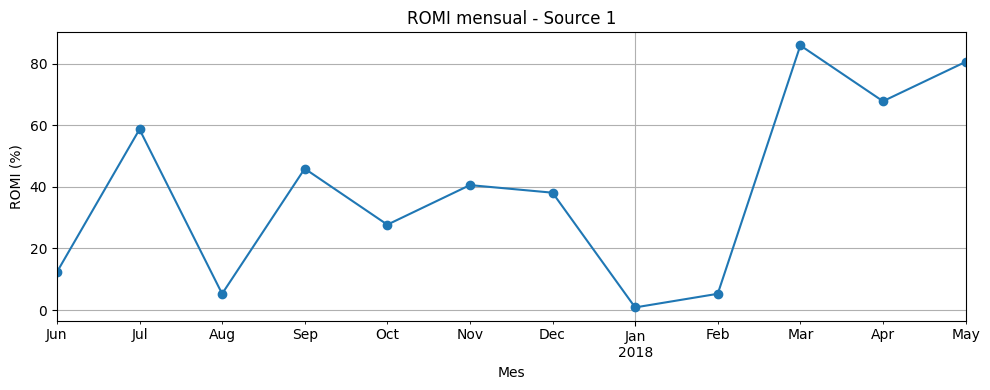

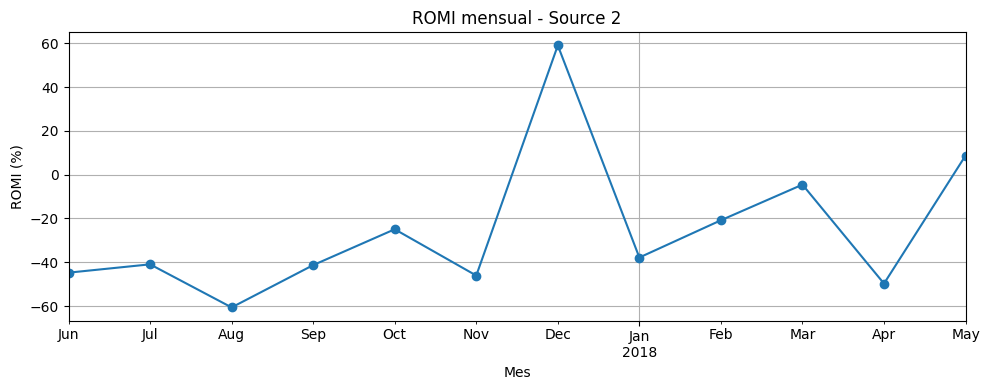

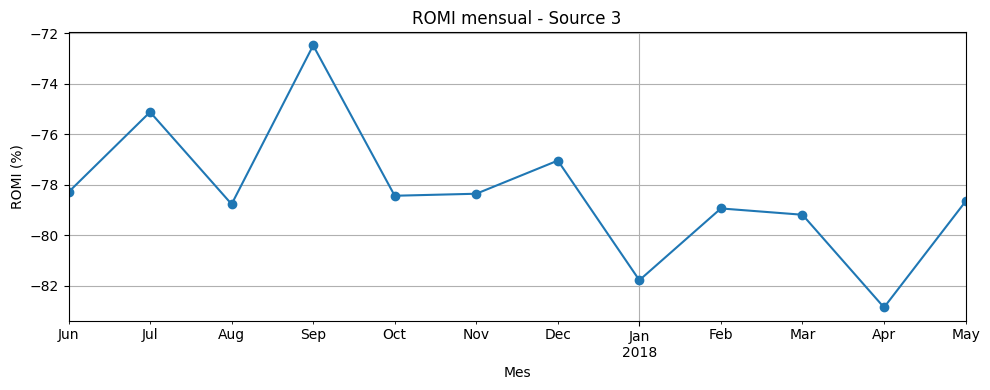

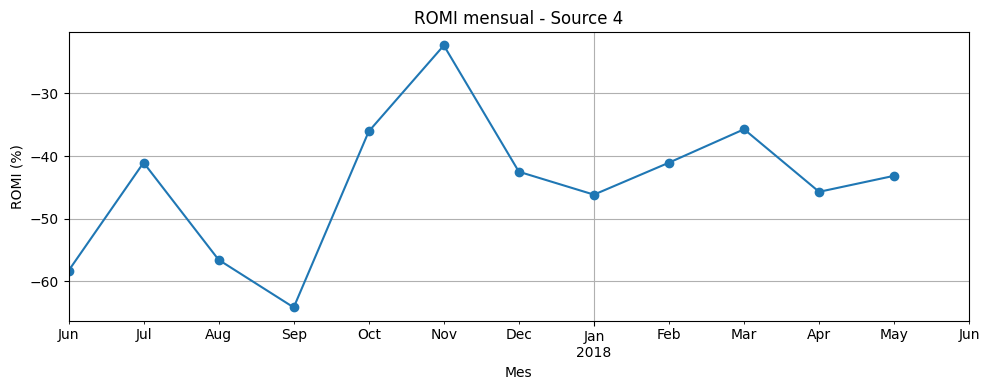

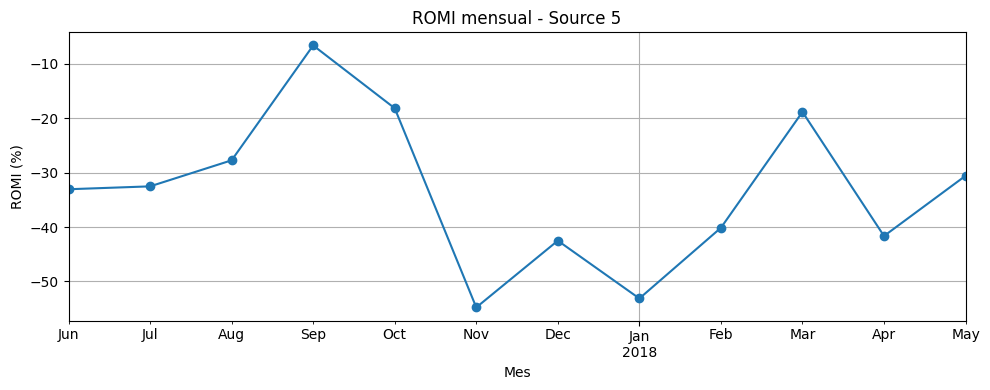

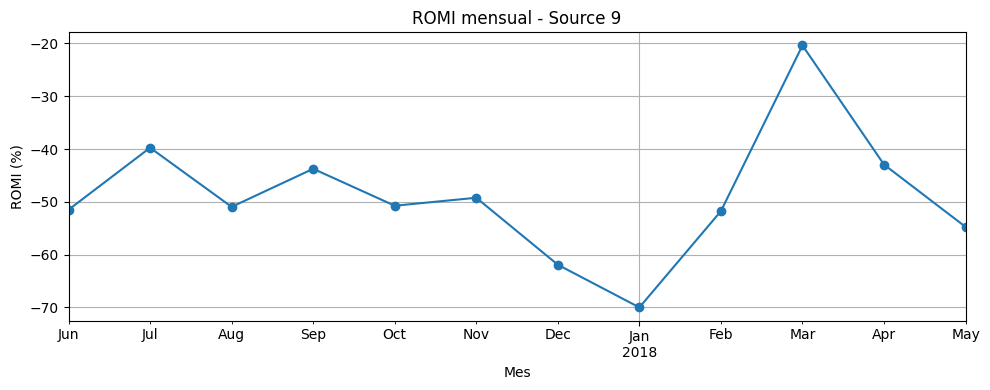

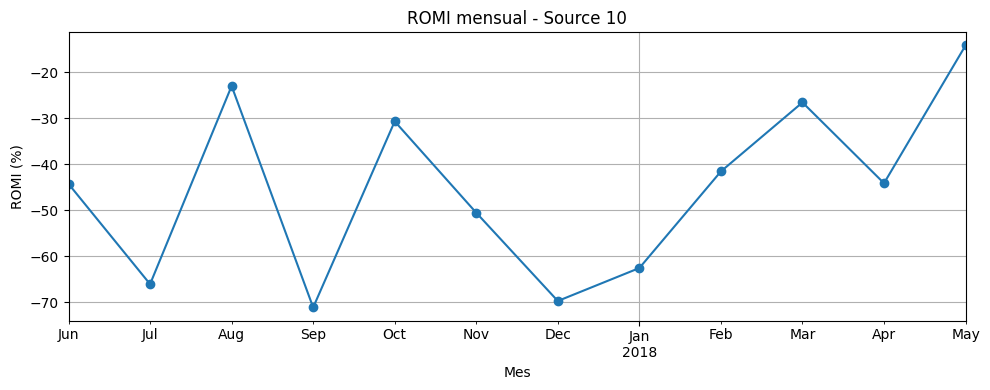

In [940]:
for i in (1,2,3,4,5,9,10):
    a = vis_ord[vis_ord['source_id'] == i].groupby('compra_mes')['revenue'].sum()
    b = costos[costos['source_id'] == i].groupby('dt_mes')['costs'].sum()
    romi = ((a - b) / b) * 100

    plt.figure(figsize=(10, 4))
    romi.plot(marker='o')
    plt.title(f"ROMI mensual - Source {i}")
    plt.ylabel("ROMI (%)")
    plt.xlabel("Mes")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/ROMI_source_{i}.png', dpi=300)
    plt.show()

El análisis del ROMI mensual revela que solo la Source 1 genera consistentemente retornos positivos, con picos de hasta 85% en marzo de 2018, lo que indica campañas de marketing rentables. En contraste, las Sources 2 a 10 muestran en su mayoría ROMIs negativos, reflejando que los costos superaron los ingresos generados, especialmente Source 3 con valores cercanos al -80% durante todo el período. Esto sugiere que estas fuentes no están justificando su inversión y deben ser optimizadas o incluso descontinuadas. 

# Conclusiones y recomendaciones

## Fuentes ganadoras

Las plataformas ganadoras son la Fuente 1 y la Fuente 2, ya que muestran una combinación sólida de LTV elevado (promedios cercanos o superiores a 6 meses), retención constante en el tiempo y ROMI positivo o cercano al equilibrio. En el caso de Fuente 1, aunque el CAC es alto (\~1100 USD), se compensa con un retorno de inversión positivo en varios meses, indicando eficiencia a largo plazo. Fuente 2, por su parte, mantiene un CAC moderado (~$470) con un ROMI más variable, pero presenta un buen equilibrio entre inversión y valor generado.

Las fuentes 3, 4 y 5 presentan CAC bajos, pero su ROMI es consistentemente negativo, lo que indica que, a pesar de adquirir usuarios de manera económica, estos no generan suficiente valor. Las fuentes 9 y 10 tienen un CAC extremadamente alto (>4000$) y ROMIs negativos persistentes, lo que las posiciona como las menos rentables. En resumen, se prioriza invertir en fuentes con un balance positivo entre adquisición, valor del cliente y retorno financiero.

## Presupuesto óptimo

Con base en los resultados, se recomienda un presupuesto total de 10 000 USD enfocado en potenciar las fuentes con mejor desempeño. La distribución sugerida sería: 45% para Fuente 1 (4500 USD), aprovechando su rentabilidad demostrada; 30% para Fuente 2 (3000 USD) por su solidez y CAC razonable; y 15% para Fuente 3 (1500 USD), como apuesta de bajo riesgo por su bajo CAC, pero monitoreando posibles mejoras en retención y monetización.

El 10% restante (1000 USD) puede asignarse de forma experimental a fuentes 4, 5 o nuevas plataformas, con campañas de bajo presupuesto que permitan validar hipótesis o realizar pruebas A/B. Esta estrategia busca maximizar el retorno manteniendo flexibilidad ante cambios en el comportamiento del usuario o del mercado.

## Supuestos y limitaciones

Este análisis parte del supuesto de que los patrones observados en los datos históricos (LTV, CAC, ROMI y retención) se mantendrán estables en el futuro, sin grandes variaciones en comportamiento del consumidor o condiciones del mercado. También se asume que los costos reportados son completos y que los ingresos atribuibles a cada fuente se han calculado correctamente sin sesgos.

Sin embargo, hubieron limitaciones a la hora de realizar el análisis. La principal fue que no todas las ordenes se encontraban en el rango de tiempo de la sesión, lo que hizo que la unión entre ordenes y visitas tenga menos entradas que la de ordenes.